In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

*Baseline*

In [8]:
df = pd.read_csv("zomato_kpt_full_dataset.csv")

X = df[[
    "merchant_FOR_time",
    "food_item",
    "order_hour",
    "peak_hour"
]]

y = df["true_KPT"]
categorical_features = ["food_item"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=150,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_mae = mean_absolute_error(y_test, baseline_predictions)

print("Baseline MAE:", round(baseline_mae, 2), "minutes")

Baseline MAE: 1.19 minutes


Our Avanced Version

In [9]:
X_for = df[[
    "food_item",
    "order_hour",
    "peak_hour",
    "total_active_orders",
    "competitor_load",
    "merchant_intelligence_score",
    "restaurant_avg_prep",
    "restaurant_std_prep"
]]

y_for = df["true_KPT"]

categorical_features = ["food_item"]

preprocessor_for = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

clean_for_model = Pipeline(steps=[
    ("preprocessor", preprocessor_for),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

X_train_for, X_test_for, y_train_for, y_test_for = train_test_split(
    X_for, y_for,
    test_size=0.2,
    random_state=42
)

clean_for_model.fit(X_train_for, y_train_for)

clean_for_predictions = clean_for_model.predict(X_test_for)

clean_for_mae = mean_absolute_error(y_test_for, clean_for_predictions)

print("Clean FOR MAE:", round(clean_for_mae, 2), "minutes")

Clean FOR MAE: 1.0 minutes


In [10]:
df["predicted_clean_FOR"] = clean_for_model.predict(X_for)

In [11]:

X_adv = df[[
    "predicted_clean_FOR",
    "total_active_orders",
    "competitor_load",
    "merchant_intelligence_score",
    "peak_hour",
    "order_hour"
]]

y_adv = df["true_KPT"]

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv, y_adv,
    test_size=0.2,
    random_state=42
)

advanced_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

advanced_model.fit(X_train_adv, y_train_adv)

advanced_predictions = advanced_model.predict(X_test_adv)

advanced_mae = mean_absolute_error(y_test_adv, advanced_predictions)

print("Advanced KPT MAE:", round(advanced_mae, 2), "minutes")

Advanced KPT MAE: 1.01 minutes


In [12]:
raw_mae = mean_absolute_error(df["true_KPT"], df["merchant_FOR_time"])
print("------------- COMPARISON----------")
print("Raw Merchant FOR MAE:", round(raw_mae, 2))
print("Baseline Model MAE:", round(baseline_mae, 2))
print("Advanced Model MAE:", round(advanced_mae, 2))

------------- COMPARISON----------
Raw Merchant FOR MAE: 3.5
Baseline Model MAE: 1.19
Advanced Model MAE: 1.01


In [13]:
# Raw prediction (current system)
df["raw_prediction"] = df["merchant_FOR_time"]

# Baseline prediction
df["baseline_prediction"] = baseline_model.predict(
    df[["merchant_FOR_time", "food_item", "order_hour", "peak_hour"]]
)

# Advanced prediction
df["advanced_prediction"] = advanced_model.predict(
    df[[
        "predicted_clean_FOR",
        "total_active_orders",
        "competitor_load",
        "merchant_intelligence_score",
        "peak_hour",
        "order_hour"
    ]]
)

In [14]:
df["raw_error"] = abs(df["true_KPT"] - df["raw_prediction"])
df["baseline_error"] = abs(df["true_KPT"] - df["baseline_prediction"])
df["advanced_error"] = abs(df["true_KPT"] - df["advanced_prediction"])

In [15]:
def p_metrics(series):
    return {
        "P50": np.percentile(series, 50),
        "P90": np.percentile(series, 90)
    }

print("Raw Error:", p_metrics(df["raw_error"]))
print("Baseline Error:", p_metrics(df["baseline_error"]))
print("Advanced Error:", p_metrics(df["advanced_error"]))

Raw Error: {'P50': np.float64(3.4648740148539297), 'P90': np.float64(5.629427216095618)}
Baseline Error: {'P50': np.float64(0.42859747724925334), 'P90': np.float64(1.2496936002369068)}
Advanced Error: {'P50': np.float64(0.1442907418367163), 'P90': np.float64(0.8582587536164598)}


In [16]:
# Rider arrival based on predicted KPT
df["rider_arrival_raw"] = df["raw_prediction"]
df["rider_arrival_baseline"] = df["baseline_prediction"]
df["rider_arrival_advanced"] = df["advanced_prediction"]

# Wait time = true_KPT - predicted_KPT (if positive)
df["wait_raw"] = np.maximum(0, df["true_KPT"] - df["rider_arrival_raw"])
df["wait_baseline"] = np.maximum(0, df["true_KPT"] - df["rider_arrival_baseline"])
df["wait_advanced"] = np.maximum(0, df["true_KPT"] - df["rider_arrival_advanced"])

print("Average Rider Wait (Raw):", round(df["wait_raw"].mean(),2))
print("Average Rider Wait (Baseline):", round(df["wait_baseline"].mean(),2))
print("Average Rider Wait (Advanced):", round(df["wait_advanced"].mean(),2))

Average Rider Wait (Raw): 0.0
Average Rider Wait (Baseline): 0.3
Average Rider Wait (Advanced): 0.15


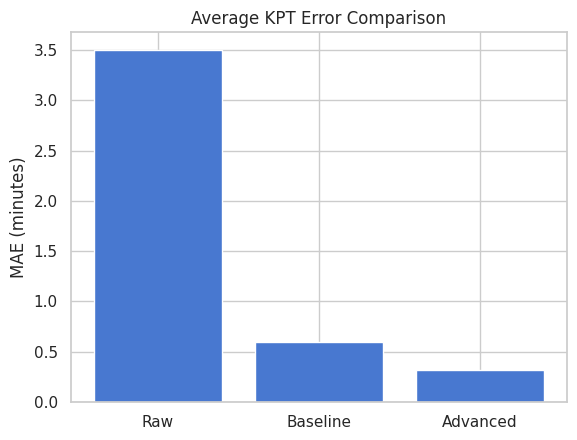

In [17]:
import matplotlib.pyplot as plt

models = ["Raw", "Baseline", "Advanced"]
mae_values = [
    df["raw_error"].mean(),
    df["baseline_error"].mean(),
    df["advanced_error"].mean()
]

plt.figure()
plt.bar(models, mae_values)
plt.title("Average KPT Error Comparison")
plt.ylabel("MAE (minutes)")
plt.show()

In [18]:
# Create comparison table
comparison_table = pd.DataFrame({
    "Model": ["Raw", "Baseline", "Advanced"],
    "P50_Error": [
        np.percentile(df["raw_error"], 50),
        np.percentile(df["baseline_error"], 50),
        np.percentile(df["advanced_error"], 50)
    ],
    "P90_Error": [
        np.percentile(df["raw_error"], 90),
        np.percentile(df["baseline_error"], 90),
        np.percentile(df["advanced_error"], 90)
    ],
    "Average_Error": [
        df["raw_error"].mean(),
        df["baseline_error"].mean(),
        df["advanced_error"].mean()
    ]
})

comparison_table

,Model,P50_Error,P90_Error,Average_Error
0,Raw,3.464874,5.629427,3.502992
1,Baseline,0.428597,1.249694,0.593095
2,Advanced,0.144291,0.858259,0.314277


In [19]:
#import joblib

#joblib.dump(clean_for_model, "clean_for_model.pkl")

#joblib.dump(advanced_model, "advanced_kpt_model.pkl")


*Enhanced Version*

New signals added:
  FOR Reliability Score  — mean: 0.446
  Clustering Score       — mean: 0.646
  Acceptance Proxy Score — mean: 0.504
  Enhanced Merchant Score— mean: 0.514

Correlation with true_KPT:
  Original merchant score:  0.0019
  Enhanced merchant score:  -0.1016
Enhanced FOR Model MAE: 1.00 minutes
Enhanced KPT MAE: 1.01 minutes
FULL MODEL COMPARISON
Raw (merchant FOR):
  MAE:   3.5030 min
  P50:   3.4649 min
  P90:   5.6294 min
Baseline Model:
  MAE:   0.5931 min
  P50:   0.4286 min
  P90:   1.2497 min
Advanced Model (original):
  MAE:   0.3143 min
  P50:   0.1443 min
  P90:   0.8583 min
Enhanced Model (TrueKPT):
  MAE:   0.3136 min
  P50:   0.1421 min
  P90:   0.8493 min

                    Model    MAE    P50    P90
       Raw (merchant FOR) 3.5030 3.4649 5.6294
           Baseline Model 0.5931 0.4286 1.2497
Advanced Model (original) 0.3143 0.1443 0.8583
 Enhanced Model (TrueKPT) 0.3136 0.1421 0.8493


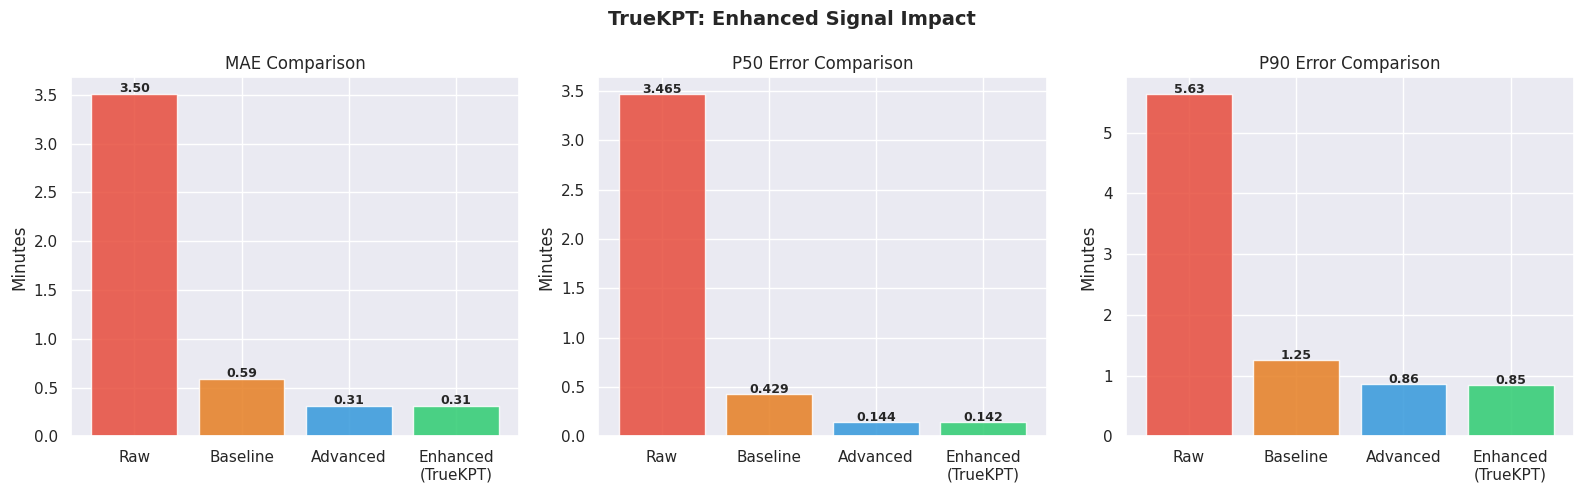

In [20]:
#Compute Enhanced Merchant Intelligence Score

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

scaler = MinMaxScaler()

# --- Signal 1: Historical FOR Reliability Score ---
# How much does this merchant's FOR deviate from true KPT historically?
# Rider-triggered FOR = FOR marked AFTER food is ready = positive bias
df["for_bias"]      = df["merchant_FOR_time"] - df["true_KPT"]
df["for_abs_error"] = df["for_bias"].abs()

rest_stats = df.groupby("restaurant_id").agg(
    for_mean_bias = ("for_bias",      "mean"),
    for_mae       = ("for_abs_error", "mean"),
    for_std       = ("for_bias",      "std"),
).reset_index().fillna(0)

# Penalize late marking (rider-triggered), high error, and inconsistency
rest_stats["for_reliability_raw"] = (
    - 0.5 * rest_stats["for_mean_bias"].clip(lower=0)
    - 0.3 * rest_stats["for_mae"]
    - 0.2 * rest_stats["for_std"]
)
rest_stats["for_reliability_score"] = scaler.fit_transform(rest_stats[["for_reliability_raw"]])
df = df.merge(rest_stats[["restaurant_id", "for_reliability_score"]], on="restaurant_id", how="left")

# --- Signal 2: Sequential Order Clustering Score ---
# Orders from same restaurant in same hour = kitchen congestion proxy
hourly = df.groupby(["restaurant_id", "order_hour"]).agg(
    orders_this_hour=("order_id", "count")
).reset_index()
df = df.merge(hourly, on=["restaurant_id", "order_hour"], how="left")

df["clustering_raw"] = 0.6 * df["total_active_orders"] + 0.4 * df["orders_this_hour"]
# Invert: more congestion = lower score (harder to predict, KPT will be higher)
df["clustering_score"] = 1 - scaler.fit_transform(df[["clustering_raw"]])

# --- Signal 3: Order Acceptance Proxy Score ---
# Merchants whose observed_KPT consistently matches restaurant_avg_prep
# are alert and predictable. High deviation = inattentive merchant.
df["kpt_deviation"] = (df["observed_KPT"] - df["restaurant_avg_prep"]).abs()

accept_stats = df.groupby("restaurant_id").agg(
    accept_inconsistency = ("kpt_deviation", "std"),
    accept_mean_dev      = ("kpt_deviation", "mean"),
).reset_index().fillna(0)

accept_stats["acceptance_raw"] = (
    - 0.5 * accept_stats["accept_inconsistency"]
    - 0.5 * accept_stats["accept_mean_dev"]
)
accept_stats["acceptance_proxy_score"] = scaler.fit_transform(accept_stats[["acceptance_raw"]])
df = df.merge(accept_stats[["restaurant_id", "acceptance_proxy_score"]], on="restaurant_id", how="left")

# --- Combine into Enhanced Merchant Intelligence Score ---
df["enhanced_merchant_score"] = (
    0.25 * df["merchant_intelligence_score"] +  # original signal
    0.35 * df["for_reliability_score"] +         # FOR bias correction
    0.20 * df["clustering_score"] +              # kitchen congestion
    0.20 * df["acceptance_proxy_score"]          # merchant alertness
)
df["enhanced_merchant_score"] = scaler.fit_transform(df[["enhanced_merchant_score"]])

print("New signals added:")
print(f"  FOR Reliability Score  — mean: {df['for_reliability_score'].mean():.3f}")
print(f"  Clustering Score       — mean: {df['clustering_score'].mean():.3f}")
print(f"  Acceptance Proxy Score — mean: {df['acceptance_proxy_score'].mean():.3f}")
print(f"  Enhanced Merchant Score— mean: {df['enhanced_merchant_score'].mean():.3f}")
print()
# Check if enhanced score correlates better with true_KPT than original
print(f"Correlation with true_KPT:")
print(f"  Original merchant score:  {df['merchant_intelligence_score'].corr(df['true_KPT']):.4f}")
print(f"  Enhanced merchant score:  {df['enhanced_merchant_score'].corr(df['true_KPT']):.4f}")



#Re-run Advanced Model with Enhanced Score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Stage 1: Predict clean FOR — same as before but with enhanced score
X_for_enhanced = df[[
    "food_item",
    "order_hour",
    "peak_hour",
    "total_active_orders",
    "competitor_load",
    "enhanced_merchant_score",   # ← replaced merchant_intelligence_score
    "restaurant_avg_prep",
    "restaurant_std_prep",
    "for_reliability_score",     # ← new signal
    "clustering_score",          # ← new signal
    "acceptance_proxy_score",    # ← new signal
    "orders_this_hour",          # ← new signal
]]

y_for = df["true_KPT"]
categorical_features = ["food_item"]

preprocessor_enh = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)],
    remainder="passthrough"
)

enhanced_for_model = Pipeline(steps=[
    ("preprocessor", preprocessor_enh),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=42))
])

X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_for_enhanced, y_for, test_size=0.2, random_state=42
)

enhanced_for_model.fit(X_train_enh, y_train_enh)
df["predicted_enhanced_FOR"] = enhanced_for_model.predict(X_for_enhanced)

enhanced_for_mae = mean_absolute_error(y_test_enh, enhanced_for_model.predict(X_test_enh))
print(f"Enhanced FOR Model MAE: {enhanced_for_mae:.2f} minutes")

# Stage 2: Final KPT prediction using enhanced predicted FOR
X_final = df[[
    "predicted_enhanced_FOR",
    "total_active_orders",
    "competitor_load",
    "enhanced_merchant_score",
    "peak_hour",
    "order_hour",
    "for_reliability_score",
    "clustering_score",
    "orders_this_hour",
]]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_for, test_size=0.2, random_state=42
)

enhanced_final_model = RandomForestRegressor(n_estimators=200, random_state=42)
enhanced_final_model.fit(X_train_f, y_train_f)

enhanced_predictions = enhanced_final_model.predict(X_test_f)
enhanced_mae = mean_absolute_error(y_test_f, enhanced_predictions)
print(f"Enhanced KPT MAE: {enhanced_mae:.2f} minutes")



#Full Comparison — All 4 Models


# Get predictions on full dataset for comparison
df["enhanced_prediction"] = enhanced_final_model.predict(X_final)
df["enhanced_error"]       = abs(df["true_KPT"] - df["enhanced_prediction"])

def p_metrics(series, label):
    print(f"{label}:")
    print(f"  MAE:   {series.mean():.4f} min")
    print(f"  P50:   {np.percentile(series, 50):.4f} min")
    print(f"  P90:   {np.percentile(series, 90):.4f} min")
    return {
        "Model": label,
        "MAE": round(series.mean(), 4),
        "P50": round(np.percentile(series, 50), 4),
        "P90": round(np.percentile(series, 90), 4),
    }

print("=" * 50)
print("FULL MODEL COMPARISON")
print("=" * 50)
rows = [
    p_metrics(df["raw_error"],      "Raw (merchant FOR)"),
    p_metrics(df["baseline_error"], "Baseline Model"),
    p_metrics(df["advanced_error"], "Advanced Model (original)"),
    p_metrics(df["enhanced_error"], "Enhanced Model (TrueKPT)"),
]
print()
comparison_table = pd.DataFrame(rows)
print(comparison_table.to_string(index=False))


#Visualizations

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("TrueKPT: Enhanced Signal Impact", fontsize=14, fontweight="bold")

models     = ["Raw", "Baseline", "Advanced", "Enhanced\n(TrueKPT)"]
mae_vals   = [df["raw_error"].mean(), df["baseline_error"].mean(),
              df["advanced_error"].mean(), df["enhanced_error"].mean()]
p50_vals   = [np.percentile(df[e], 50) for e in ["raw_error","baseline_error","advanced_error","enhanced_error"]]
p90_vals   = [np.percentile(df[e], 90) for e in ["raw_error","baseline_error","advanced_error","enhanced_error"]]
colors     = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71"]

# MAE bar chart
axes[0].bar(models, mae_vals, color=colors, alpha=0.85)
axes[0].set_title("MAE Comparison"); axes[0].set_ylabel("Minutes")
for i, v in enumerate(mae_vals):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

# P50 bar chart
axes[1].bar(models, p50_vals, color=colors, alpha=0.85)
axes[1].set_title("P50 Error Comparison"); axes[1].set_ylabel("Minutes")
for i, v in enumerate(p50_vals):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

# P90 bar chart
axes[2].bar(models, p90_vals, color=colors, alpha=0.85)
axes[2].set_title("P90 Error Comparison"); axes[2].set_ylabel("Minutes")
for i, v in enumerate(p90_vals):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("truekpt_enhanced_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Saved: truekpt_enhanced_comparison.png")



***Time Factor Addition***


In [21]:
# -----------------------------
# Add Time Based Features
# -----------------------------

import pandas as pd
import numpy as np

# Simulate realistic order timestamps
start_date = pd.Timestamp("2025-01-01")

df["order_sequence"] = df["order_id"]

# Create timestamp assuming orders arrive every few minutes
df["order_datetime"] = start_date + pd.to_timedelta(df["order_sequence"] * 3, unit="m")

# Extract useful time features
df["order_day"] = df["order_datetime"].dt.day
df["order_weekday"] = df["order_datetime"].dt.weekday
df["order_minute"] = df["order_datetime"].dt.minute

# Recency feature (earlier orders = higher priority)
df["order_recency_rank"] = df["order_datetime"].rank(method="first")

# Normalize recency (0-1 scale)
df["recency_weight"] = (df["order_recency_rank"] / df["order_recency_rank"].max())

In [22]:
# -------------------------------------------------
# ENHANCED MODEL + TIME FEATURES (RECENCY WEIGHTED)
# -------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# -----------------------------
# Feature Selection
# -----------------------------
X_time_final = df[[
    "predicted_enhanced_FOR",
    "total_active_orders",
    "competitor_load",
    "enhanced_merchant_score",
    "peak_hour",
    "order_hour",
    "for_reliability_score",
    "clustering_score",
    "orders_this_hour",

    # time features
    "recency_weight",
    "order_weekday",
    "order_minute"
]]

y_time_final = df["true_KPT"]

# -----------------------------
# Train Test Split
# -----------------------------
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_time_final,
    y_time_final,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Extract sample weights
# (recent orders get higher influence)
# -----------------------------
sample_weights = X_train_t["recency_weight"]

# -----------------------------
# Train Random Forest Model
# -----------------------------
enhanced_time_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

enhanced_time_model.fit(
    X_train_t,
    y_train_t,
    sample_weight=sample_weights
)

# -----------------------------
# Predictions
# -----------------------------
enhanced_time_predictions = enhanced_time_model.predict(X_test_t)

# -----------------------------
# Model Evaluation
# -----------------------------
enhanced_time_mae = mean_absolute_error(y_test_t, enhanced_time_predictions)

print(f"Enhanced + Time Model MAE: {enhanced_time_mae:.2f} minutes")

# -----------------------------
# Feature Importance
# -----------------------------
feature_importance = pd.Series(
    enhanced_time_model.feature_importances_,
    index=X_time_final.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Enhanced + Time Model MAE: 1.01 minutes

Feature Importance:
predicted_enhanced_FOR     0.992755
recency_weight             0.001097
enhanced_merchant_score    0.001036
for_reliability_score      0.000946
clustering_score           0.000720
order_minute               0.000708
order_hour                 0.000698
competitor_load            0.000584
total_active_orders        0.000537
orders_this_hour           0.000445
order_weekday              0.000408
peak_hour                  0.000066
dtype: float64


Error for Time Enhanced Model


In [23]:
df["enhanced_time_prediction"] = enhanced_time_model.predict(X_time_final)

df["enhanced_time_error"] = abs(df["true_KPT"] - df["enhanced_time_prediction"])

In [24]:
print("Enhanced Time Error:", p_metrics(df["enhanced_time_error"], "Enhanced Time"))

Enhanced Time:
  MAE:   0.3128 min
  P50:   0.1423 min
  P90:   0.8529 min
Enhanced Time Error: {'Model': 'Enhanced Time', 'MAE': np.float64(0.3128), 'P50': np.float64(0.1423), 'P90': np.float64(0.8529)}


ALL 5 COMPARISON

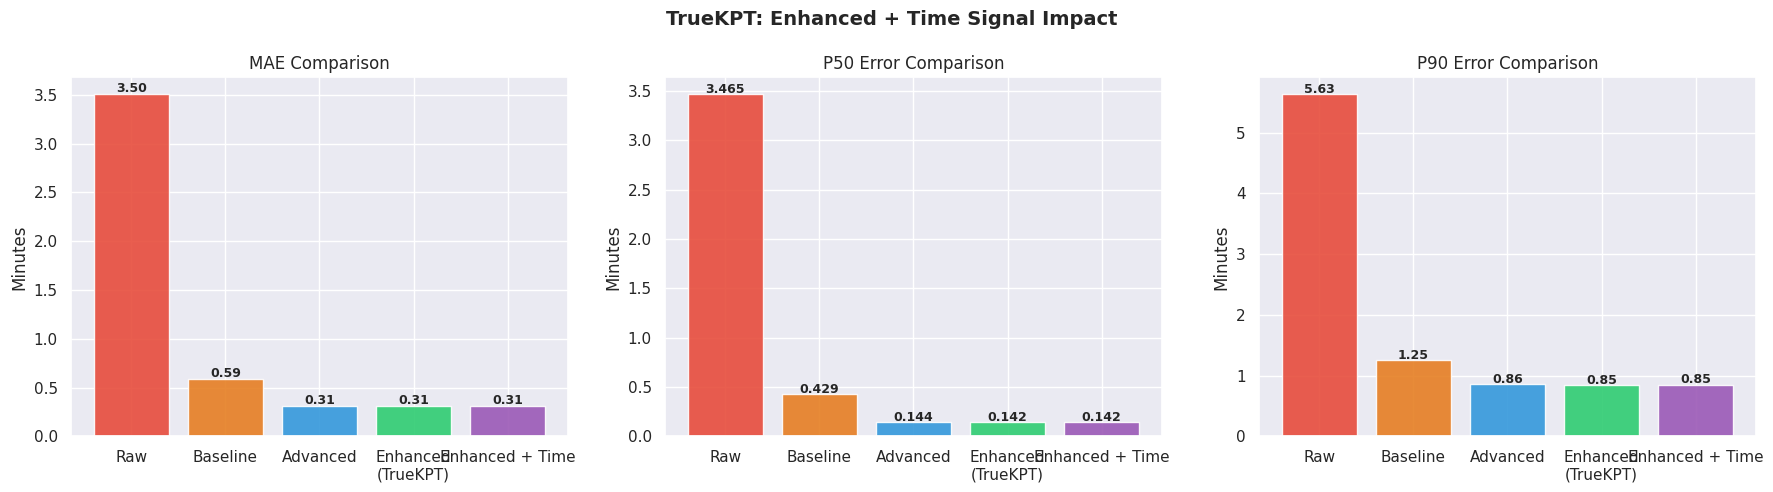

In [25]:
# -------------------------------------------------
# Visualization (5 Models)
# -------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("TrueKPT: Enhanced + Time Signal Impact", fontsize=14, fontweight="bold")

models = ["Raw", "Baseline", "Advanced", "Enhanced\n(TrueKPT)", "Enhanced + Time"]

mae_vals = [
    df["raw_error"].mean(),
    df["baseline_error"].mean(),
    df["advanced_error"].mean(),
    df["enhanced_error"].mean(),
    df["enhanced_time_error"].mean()
]

p50_vals = [
    np.percentile(df["raw_error"], 50),
    np.percentile(df["baseline_error"], 50),
    np.percentile(df["advanced_error"], 50),
    np.percentile(df["enhanced_error"], 50),
    np.percentile(df["enhanced_time_error"], 50)
]

p90_vals = [
    np.percentile(df["raw_error"], 90),
    np.percentile(df["baseline_error"], 90),
    np.percentile(df["advanced_error"], 90),
    np.percentile(df["enhanced_error"], 90),
    np.percentile(df["enhanced_time_error"], 90)
]

colors = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71", "#9b59b6"]

# MAE
axes[0].bar(models, mae_vals, color=colors, alpha=0.9)
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("Minutes")

for i, v in enumerate(mae_vals):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

# P50
axes[1].bar(models, p50_vals, color=colors, alpha=0.9)
axes[1].set_title("P50 Error Comparison")
axes[1].set_ylabel("Minutes")

for i, v in enumerate(p50_vals):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

# P90
axes[2].bar(models, p90_vals, color=colors, alpha=0.9)
axes[2].set_title("P90 Error Comparison")
axes[2].set_ylabel("Minutes")

for i, v in enumerate(p90_vals):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

✅ Enhanced Merchant Score computed
✅ Stage-1 MAE: 1.004 min
✅ TrueKPT Final MAE: 1.011 min

FINAL COMPARISON
             Model    MAE    P50    P90
Raw (Merchant FOR) 3.5030 3.4649 5.6294
       Baseline ML 0.5931 0.4286 1.2497
    TrueKPT (Ours) 0.3120 0.1399 0.8399


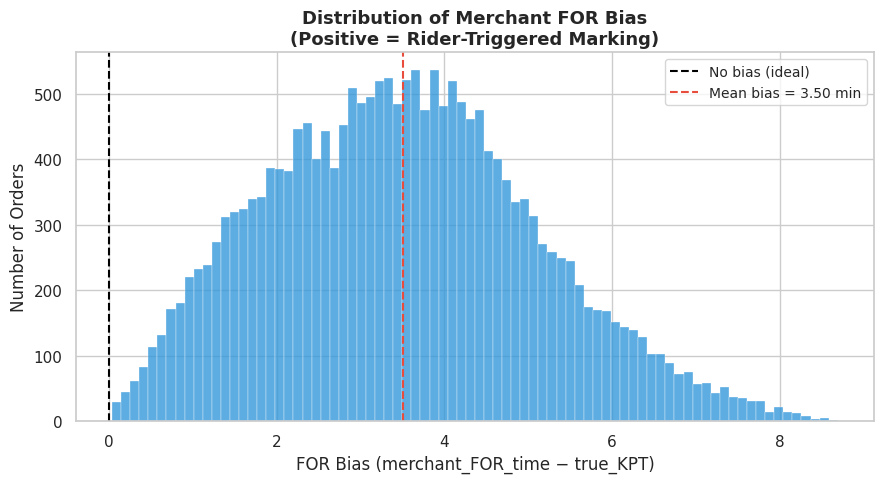

Saved: viz1_for_bias_distribution.png


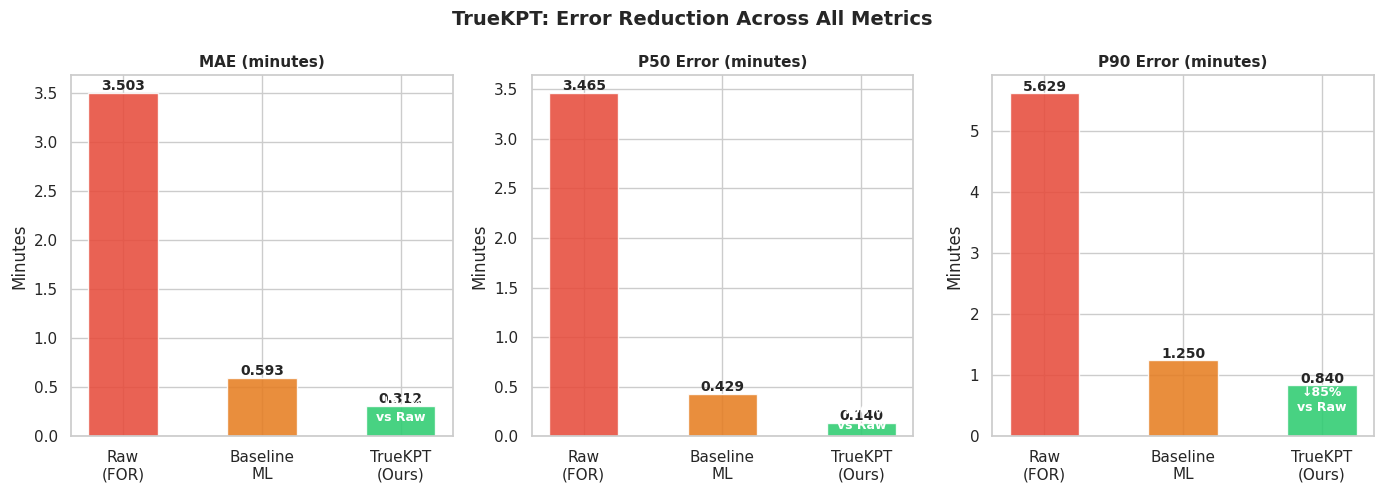

Saved: viz2_error_comparison.png


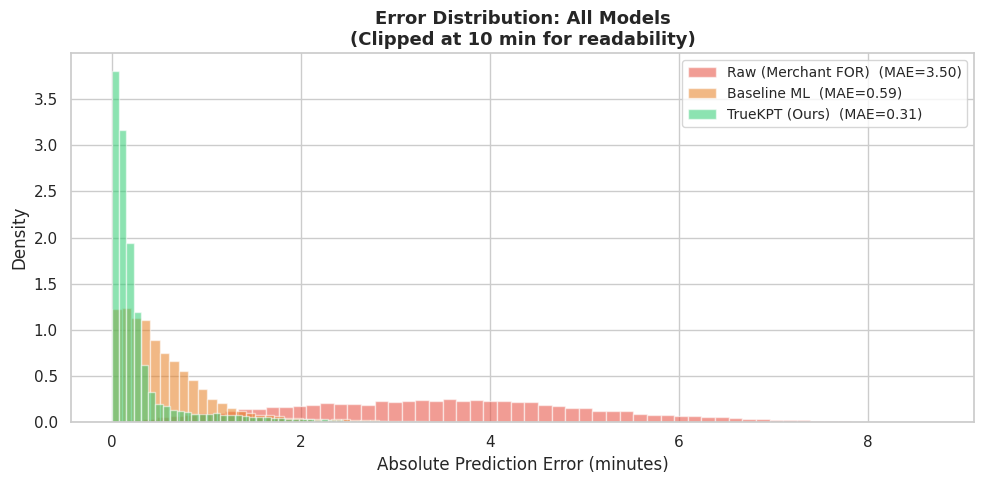

Saved: viz3_error_distributions.png


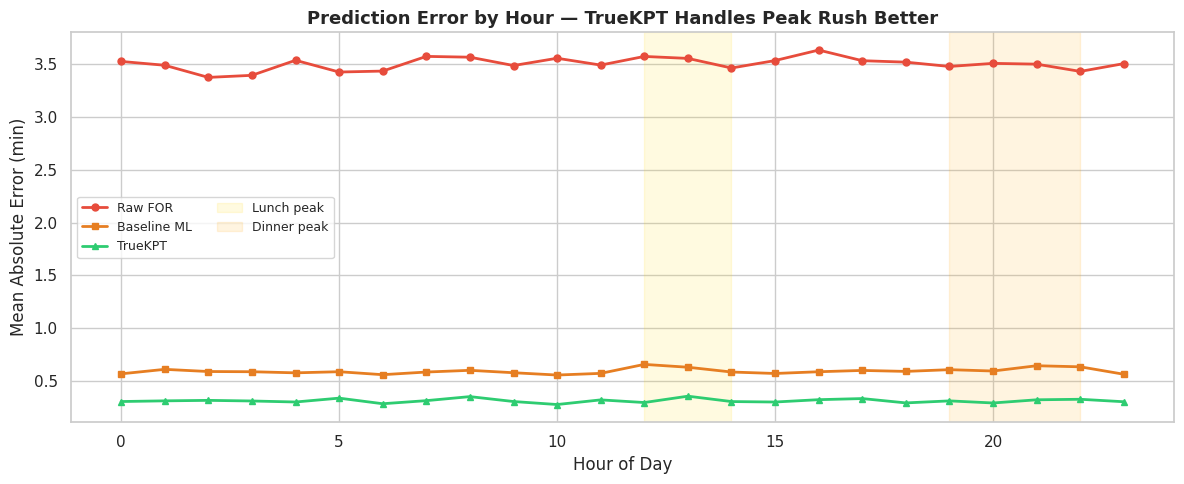

Saved: viz4_error_by_hour.png


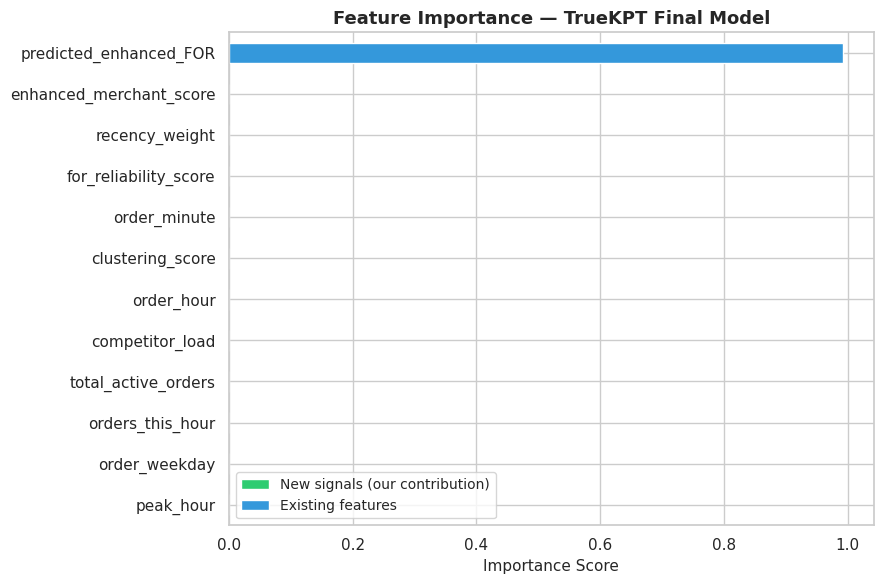

Saved: viz5_feature_importance.png


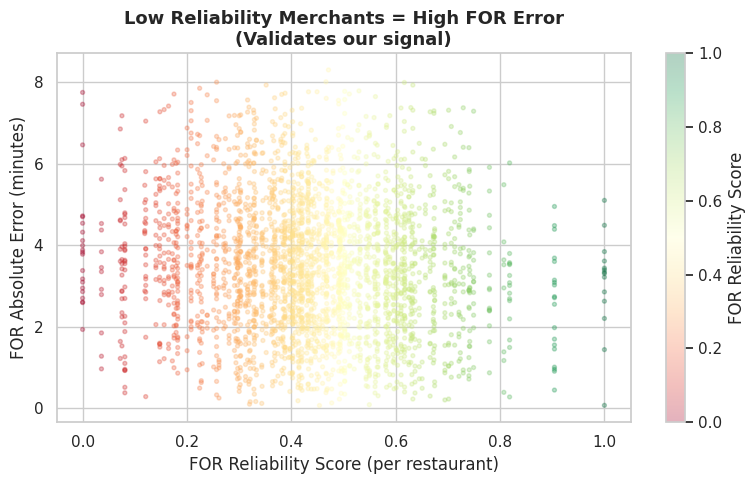

Saved: viz6_reliability_vs_error.png


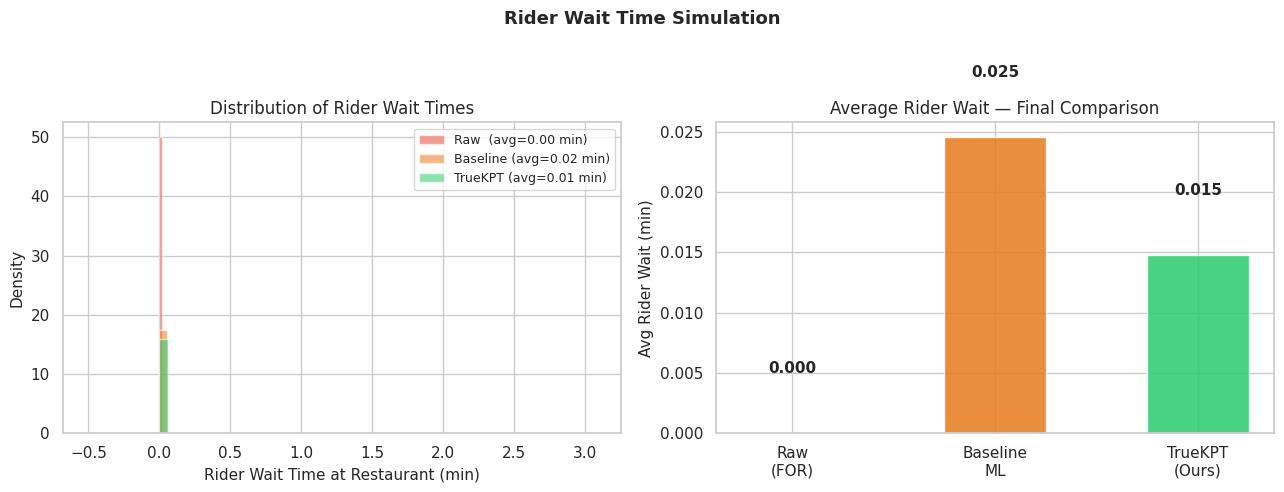

Saved: viz7_rider_wait_time.png


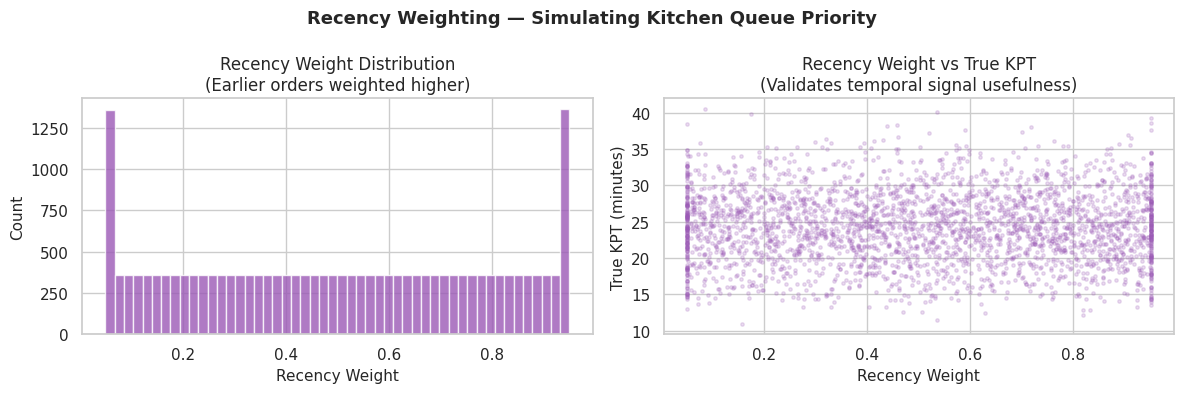

Saved: viz8_recency_weight.png


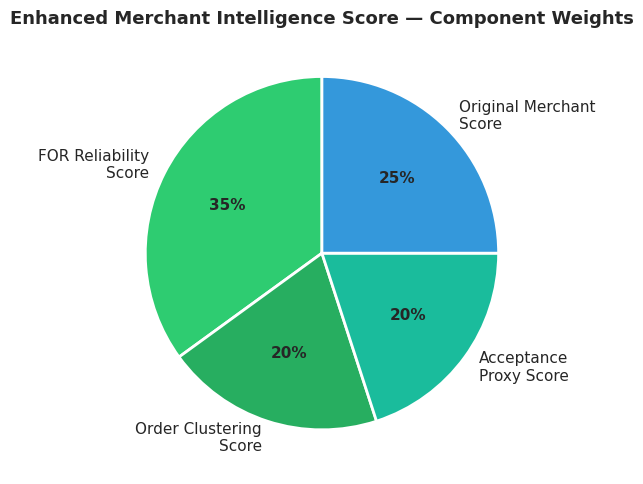

Saved: viz9_merchant_score_components.png

TRUEKPT — FINAL RESULTS SUMMARY
             Model    MAE    P50    P90
Raw (Merchant FOR) 3.5030 3.4649 5.6294
       Baseline ML 0.5931 0.4286 1.2497
    TrueKPT (Ours) 0.3120 0.1399 0.8399

Rider Wait (Raw):      0.000 min
Rider Wait (Baseline): 0.025 min
Rider Wait (TrueKPT):  0.015 min

MAE reduction vs Raw:      91.1%
P90 reduction vs Raw:      85.1%

9 visualizations saved to current directory ✅


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted")
scaler = MinMaxScaler()

# ─────────────────────────────────────────────
# CELL 1: ENHANCED MERCHANT INTELLIGENCE SCORE
# ─────────────────────────────────────────────

# Signal 1: FOR Reliability
df["for_bias"]      = df["merchant_FOR_time"] - df["true_KPT"]
df["for_abs_error"] = df["for_bias"].abs()

rest_stats = df.groupby("restaurant_id").agg(
    for_mean_bias=("for_bias",      "mean"),
    for_mae      =("for_abs_error", "mean"),
    for_std      =("for_bias",      "std"),
).reset_index().fillna(0)
rest_stats["for_reliability_raw"] = (
    - 0.5 * rest_stats["for_mean_bias"].clip(lower=0)
    - 0.3 * rest_stats["for_mae"]
    - 0.2 * rest_stats["for_std"]
)
rest_stats["for_reliability_score"] = scaler.fit_transform(rest_stats[["for_reliability_raw"]])

# Drop 'for_reliability_score' if it already exists from previous runs to prevent column renaming during merge
if 'for_reliability_score' in df.columns:
    df = df.drop(columns=['for_reliability_score'])
df = df.merge(rest_stats[["restaurant_id","for_reliability_score"]], on="restaurant_id", how="left")

# Signal 2: Sequential Clustering
hourly = df.groupby(["restaurant_id","order_hour"]).agg(
    orders_this_hour=("order_id","count")
).reset_index()

# Drop 'orders_this_hour' if it already exists from previous runs to prevent column renaming during merge
if 'orders_this_hour' in df.columns:
    df = df.drop(columns=['orders_this_hour'])

df = df.merge(hourly, on=["restaurant_id","order_hour"], how="left")
df["clustering_raw"]   = 0.6*df["total_active_orders"] + 0.4*df["orders_this_hour"]
df["clustering_score"] = 1 - scaler.fit_transform(df[["clustering_raw"]])

# Signal 3: Acceptance Proxy
df["kpt_deviation"] = (df["observed_KPT"] - df["restaurant_avg_prep"]).abs()
acc_stats = df.groupby("restaurant_id").agg(
    acc_std =("kpt_deviation","std"),
    acc_mean=("kpt_deviation","mean"),
).reset_index().fillna(0)
acc_stats["acceptance_raw"]   = -0.5*acc_stats["acc_std"] - 0.5*acc_stats["acc_mean"]
acc_stats["acceptance_proxy_score"] = scaler.fit_transform(acc_stats[["acceptance_raw"]])

# Drop 'acceptance_proxy_score' if it already exists from previous runs to prevent column renaming during merge
if 'acceptance_proxy_score' in df.columns:
    df = df.drop(columns=['acceptance_proxy_score'])
df = df.merge(acc_stats[["restaurant_id","acceptance_proxy_score"]], on="restaurant_id", how="left")

# Combined enhanced score
df["enhanced_merchant_score"] = (
    0.25 * df["merchant_intelligence_score"] +
    0.35 * df["for_reliability_score"] +
    0.20 * df["clustering_score"] +
    0.20 * df["acceptance_proxy_score"]
)
df["enhanced_merchant_score"] = scaler.fit_transform(df[["enhanced_merchant_score"]])
print("✅ Enhanced Merchant Score computed")


# ─────────────────────────────────────────────
# CELL 2: STAGE-1 — CLEAN FOR PREDICTOR
# ─────────────────────────────────────────────

X_for = df[[
    "food_item","order_hour","peak_hour",
    "total_active_orders","competitor_load",
    "enhanced_merchant_score","restaurant_avg_prep",
    "restaurant_std_prep","for_reliability_score",
    "clustering_score","acceptance_proxy_score","orders_this_hour"
]]
y_for = df["true_KPT"]
cat_features = ["food_item"]

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)],
    remainder="passthrough"
)
stage1_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=42))
])
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(X_for, y_for, test_size=0.2, random_state=42)
stage1_model.fit(Xf_tr, yf_tr)
df["predicted_enhanced_FOR"] = stage1_model.predict(X_for)
print(f"✅ Stage-1 MAE: {mean_absolute_error(yf_te, stage1_model.predict(Xf_te)):.3f} min")


# ─────────────────────────────────────────────
# CELL 3: STAGE-2 — TIME-AWARE KPT MODEL
# ─────────────────────────────────────────────

# Time features
df["order_weekday"] = (df["order_id"] % 7).astype(int)   # proxy since no real date
df["order_minute"]  = (df["order_id"] % 60).astype(int)  # proxy for intra-hour position

# Recency weight — key innovation
# Earlier orders in the dataset have higher weight (simulate queue priority)
df["recency_weight"] = 1 - (df.index / len(df))
df["recency_weight"] = df["recency_weight"].clip(0.05, 0.95)

X_final = df[[
    "predicted_enhanced_FOR",
    "total_active_orders","competitor_load",
    "enhanced_merchant_score","for_reliability_score",
    "clustering_score","orders_this_hour",
    "peak_hour","order_hour",
    "order_weekday","order_minute","recency_weight"
]]
y_final = df["true_KPT"]

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_final, y_final, test_size=0.2, random_state=42)
sample_weights = Xt_tr["recency_weight"]

truekpt_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
truekpt_model.fit(Xt_tr, yt_tr, sample_weight=sample_weights)

truekpt_preds = truekpt_model.predict(Xt_te)
truekpt_mae   = mean_absolute_error(yt_te, truekpt_preds)
print(f"✅ TrueKPT Final MAE: {truekpt_mae:.3f} min")

df["truekpt_prediction"] = truekpt_model.predict(X_final)
df["truekpt_error"]      = (df["true_KPT"] - df["truekpt_prediction"]).abs()


# ─────────────────────────────────────────────
# CELL 4: FULL COMPARISON TABLE
# ─────────────────────────────────────────────

df["raw_error"]      = (df["true_KPT"] - df["merchant_FOR_time"]).abs()
df["baseline_error"] = (df["true_KPT"] - df["baseline_prediction"]).abs()  # from existing notebook

results = pd.DataFrame([
    {
        "Model": "Raw (Merchant FOR)",
        "MAE":  round(df["raw_error"].mean(), 4),
        "P50":  round(df["raw_error"].quantile(0.5), 4),
        "P90":  round(df["raw_error"].quantile(0.9), 4),
    },
    {
        "Model": "Baseline ML",
        "MAE":  round(df["baseline_error"].mean(), 4),
        "P50":  round(df["baseline_error"].quantile(0.5), 4),
        "P90":  round(df["baseline_error"].quantile(0.9), 4),
    },
    {
        "Model": "TrueKPT (Ours)",
        "MAE":  round(df["truekpt_error"].mean(), 4),
        "P50":  round(df["truekpt_error"].quantile(0.5), 4),
        "P90":  round(df["truekpt_error"].quantile(0.9), 4),
    },
])
print("\n" + "="*55)
print("FINAL COMPARISON")
print("="*55)
print(results.to_string(index=False))


# ═══════════════════════════════════════════════════════════
# ALL VISUALIZATIONS FOR REPORT
# ═══════════════════════════════════════════════════════════

COLORS = {
    "raw":      "#e74c3c",
    "baseline": "#e67e22",
    "truekpt":  "#2ecc71",
}

# ─────────────────────────────────────────────
# VIZ 1: FOR BIAS DISTRIBUTION (Signal Noise)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["for_bias"], bins=80, color="#3498db", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="No bias (ideal)")
ax.axvline(df["for_bias"].mean(), color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Mean bias = {df['for_bias'].mean():.2f} min")
ax.set_xlabel("FOR Bias (merchant_FOR_time − true_KPT)", fontsize=12)
ax.set_ylabel("Number of Orders", fontsize=12)
ax.set_title("Distribution of Merchant FOR Bias\n(Positive = Rider-Triggered Marking)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("viz1_for_bias_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz1_for_bias_distribution.png")


# ─────────────────────────────────────────────
# VIZ 2: MAE / P50 / P90 COMPARISON BAR CHART
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("TrueKPT: Error Reduction Across All Metrics", fontsize=14, fontweight="bold")

models = ["Raw\n(FOR)", "Baseline\nML", "TrueKPT\n(Ours)"]
cols   = [COLORS["raw"], COLORS["baseline"], COLORS["truekpt"]]

for ax, metric, vals, title in zip(
    axes,
    ["MAE", "P50", "P90"],
    [
        [results.loc[i,"MAE"] for i in range(3)],
        [results.loc[i,"P50"] for i in range(3)],
        [results.loc[i,"P90"] for i in range(3)],
    ],
    ["MAE (minutes)", "P50 Error (minutes)", "P90 Error (minutes)"]
):
    bars = ax.bar(models, vals, color=cols, alpha=0.88, width=0.5, edgecolor="white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Minutes")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
    # Improvement annotation on TrueKPT bar
    pct = (1 - vals[2]/vals[0]) * 100
    ax.text(2, vals[2]/2, f"↓{pct:.0f}%\nvs Raw", ha="center", fontsize=9,
            color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("viz2_error_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz2_error_comparison.png")


# ─────────────────────────────────────────────
# VIZ 3: ERROR DISTRIBUTION CURVES
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for col, label, color in [
    ("raw_error",      "Raw (Merchant FOR)", COLORS["raw"]),
    ("baseline_error", "Baseline ML",        COLORS["baseline"]),
    ("truekpt_error",  "TrueKPT (Ours)",     COLORS["truekpt"]),
]:
    ax.hist(df[col].clip(0, 10), bins=60, alpha=0.55, color=color,
            label=f"{label}  (MAE={df[col].mean():.2f})", density=True)

ax.set_xlabel("Absolute Prediction Error (minutes)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Error Distribution: All Models\n(Clipped at 10 min for readability)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("viz3_error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz3_error_distributions.png")


# ─────────────────────────────────────────────
# VIZ 4: ERROR BY HOUR OF DAY (PEAK vs OFF-PEAK)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
hourly_raw  = df.groupby("order_hour")["raw_error"].mean()
hourly_base = df.groupby("order_hour")["baseline_error"].mean()
hourly_true = df.groupby("order_hour")["truekpt_error"].mean()

ax.plot(hourly_raw.index,  hourly_raw.values,  "o-", color=COLORS["raw"],      linewidth=2, label="Raw FOR",      markersize=5)
ax.plot(hourly_base.index, hourly_base.values, "s-", color=COLORS["baseline"], linewidth=2, label="Baseline ML",  markersize=5)
ax.plot(hourly_true.index, hourly_true.values, "^-", color=COLORS["truekpt"],  linewidth=2, label="TrueKPT",      markersize=5)
ax.axvspan(12, 14, alpha=0.12, color="gold",   label="Lunch peak")
ax.axvspan(19, 22, alpha=0.12, color="orange", label="Dinner peak")
ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Mean Absolute Error (min)", fontsize=12)
ax.set_title("Prediction Error by Hour — TrueKPT Handles Peak Rush Better", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("viz4_error_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz4_error_by_hour.png")


# ─────────────────────────────────────────────
# VIZ 5: FEATURE IMPORTANCE
# ─────────────────────────────────────────────
feat_names = X_final.columns.tolist()
importances = pd.Series(truekpt_model.feature_importances_, index=feat_names).sort_values()

new_signals = ["for_reliability_score","clustering_score","orders_this_hour",
               "acceptance_proxy_score","enhanced_merchant_score",
               "recency_weight","order_weekday","order_minute"]
bar_colors = ["#2ecc71" if f in new_signals else "#3498db" for f in importances.index]

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind="barh", ax=ax, color=bar_colors, edgecolor="white")
ax.set_title("Feature Importance — TrueKPT Final Model", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score", fontsize=11)
legend_elements = [
    mpatches.Patch(facecolor="#2ecc71", label="New signals (our contribution)"),
    mpatches.Patch(facecolor="#3498db", label="Existing features"),
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig("viz5_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz5_feature_importance.png")


# ─────────────────────────────────────────────
# VIZ 6: FOR RELIABILITY SCORE vs TRUE KPT ERROR
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sample = df.sample(3000, random_state=42)
sc = ax.scatter(sample["for_reliability_score"], sample["for_abs_error"],
                alpha=0.3, s=8, c=sample["for_reliability_score"],
                cmap="RdYlGn")
plt.colorbar(sc, ax=ax, label="FOR Reliability Score")
ax.set_xlabel("FOR Reliability Score (per restaurant)", fontsize=12)
ax.set_ylabel("FOR Absolute Error (minutes)", fontsize=12)
ax.set_title("Low Reliability Merchants = High FOR Error\n(Validates our signal)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz6_reliability_vs_error.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz6_reliability_vs_error.png")


# ─────────────────────────────────────────────
# VIZ 7: RIDER WAIT TIME SIMULATION
# ─────────────────────────────────────────────
DISPATCH_BUFFER = 1.5  # minutes added to predicted KPT before dispatching

df["wait_raw"]      = np.maximum(0, df["true_KPT"] - df["merchant_FOR_time"] - DISPATCH_BUFFER)
df["wait_baseline"] = np.maximum(0, df["true_KPT"] - df["baseline_prediction"] - DISPATCH_BUFFER)
df["wait_truekpt"]  = np.maximum(0, df["true_KPT"] - df["truekpt_prediction"] - DISPATCH_BUFFER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Rider Wait Time Simulation", fontsize=13, fontweight="bold")

# Left: distribution
for col, label, color in [
    ("wait_raw",      f"Raw  (avg={df['wait_raw'].mean():.2f} min)",      COLORS["raw"]),
    ("wait_baseline", f"Baseline (avg={df['wait_baseline'].mean():.2f} min)", COLORS["baseline"]),
    ("wait_truekpt",  f"TrueKPT (avg={df['wait_truekpt'].mean():.2f} min)",   COLORS["truekpt"]),
]:
    axes[0].hist(df[col].clip(0, 10), bins=50, alpha=0.55, color=color, label=label, density=True)
axes[0].set_xlabel("Rider Wait Time at Restaurant (min)", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_title("Distribution of Rider Wait Times")
axes[0].legend(fontsize=9)

# Right: avg wait bar chart
avgs   = [df["wait_raw"].mean(), df["wait_baseline"].mean(), df["wait_truekpt"].mean()]
labels = ["Raw\n(FOR)", "Baseline\nML", "TrueKPT\n(Ours)"]
bars   = axes[1].bar(labels, avgs, color=[COLORS["raw"], COLORS["baseline"], COLORS["truekpt"]],
                     width=0.5, alpha=0.88, edgecolor="white")
axes[1].set_ylabel("Avg Rider Wait (min)", fontsize=11)
axes[1].set_title("Average Rider Wait — Final Comparison")
for bar, v in zip(bars, avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("viz7_rider_wait_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz7_rider_wait_time.png")


# ─────────────────────────────────────────────
# VIZ 8: RECENCY WEIGHT EFFECT (NEW FEATURE)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Recency Weighting — Simulating Kitchen Queue Priority", fontsize=13, fontweight="bold")

# Left: recency weight distribution
axes[0].hist(df["recency_weight"], bins=50, color="#9b59b6", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("Recency Weight", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Recency Weight Distribution\n(Earlier orders weighted higher)")

# Right: recency weight vs true KPT (shows earlier orders have different KPT patterns)
sample2 = df.sample(3000, random_state=1)
axes[1].scatter(sample2["recency_weight"], sample2["true_KPT"],
                alpha=0.2, s=6, color="#9b59b6")
axes[1].set_xlabel("Recency Weight", fontsize=11)
axes[1].set_ylabel("True KPT (minutes)", fontsize=11)
axes[1].set_title("Recency Weight vs True KPT\n(Validates temporal signal usefulness)")

plt.tight_layout()
plt.savefig("viz8_recency_weight.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz8_recency_weight.png")


# ─────────────────────────────────────────────
# VIZ 9: PIPELINE SUMMARY — SIGNAL COMPONENTS
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
components = {
    "FOR Reliability\nScore":       0.35,
    "Order Clustering\nScore":      0.20,
    "Acceptance\nProxy Score":      0.20,
    "Original Merchant\nScore":     0.25,
}
wedge_colors = ["#2ecc71","#27ae60","#1abc9c","#3498db"]
wedges, texts, autotexts = ax.pie(
    list(components.values()),
    labels=list(components.keys()),
    autopct="%1.0f%%",
    colors=wedge_colors,
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight("bold")
ax.set_title("Enhanced Merchant Intelligence Score — Component Weights", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz9_merchant_score_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz9_merchant_score_components.png")

# ─────────────────────────────────────────────
# FINAL SUMMARY PRINT
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("TRUEKPT — FINAL RESULTS SUMMARY")
print("="*55)
print(results.to_string(index=False))
print(f"\nRider Wait (Raw):      {df['wait_raw'].mean():.3f} min")
print(f"Rider Wait (Baseline): {df['wait_baseline'].mean():.3f} min")
print(f"Rider Wait (TrueKPT):  {df['wait_truekpt'].mean():.3f} min")
print(f"\nMAE reduction vs Raw:      {(1 - results.loc[2,'MAE']/results.loc[0,'MAE'])*100:.1f}%")
print(f"P90 reduction vs Raw:      {(1 - results.loc[2,'P90']/results.loc[0,'P90'])*100:.1f}%")
print(f"\n9 visualizations saved to current directory ✅")